# Exploratory Data Analysis (EDA)
This notebook performs Exploratory Data Analysis on the Telco Customer Churn dataset and generates initial visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Create reports/images directory if it doesn't exist
os.makedirs('../reports/images', exist_ok=True)

## 1. Load Dataset

In [2]:
df = pd.read_csv('../data/Telco-Customer-Churn.csv')
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Basic Dataset Info

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 3. Churn Distribution (Pie and Count Plot)

C:\Users\kp941\AppData\Local\Temp\ipykernel_19504\610471239.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette=['#4CAF50', '#FF5722'])


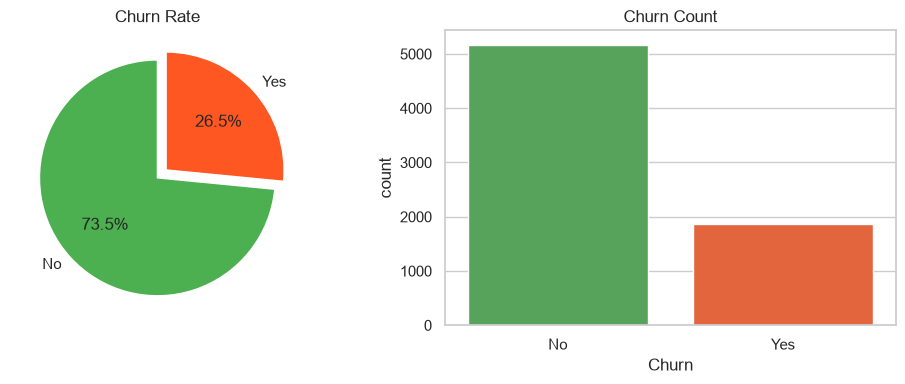

In [4]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#4CAF50', '#FF5722'], explode=[0, 0.1], startangle=90)
plt.title('Churn Rate')
plt.ylabel('')

plt.subplot(1, 2, 2)
sns.countplot(x='Churn', data=df, palette=['#4CAF50', '#FF5722'])
plt.title('Churn Count')

plt.tight_layout()
plt.savefig('../reports/images/churn_distribution.png', dpi=300)
plt.show()

## 4. Gender and Demographics vs Churn

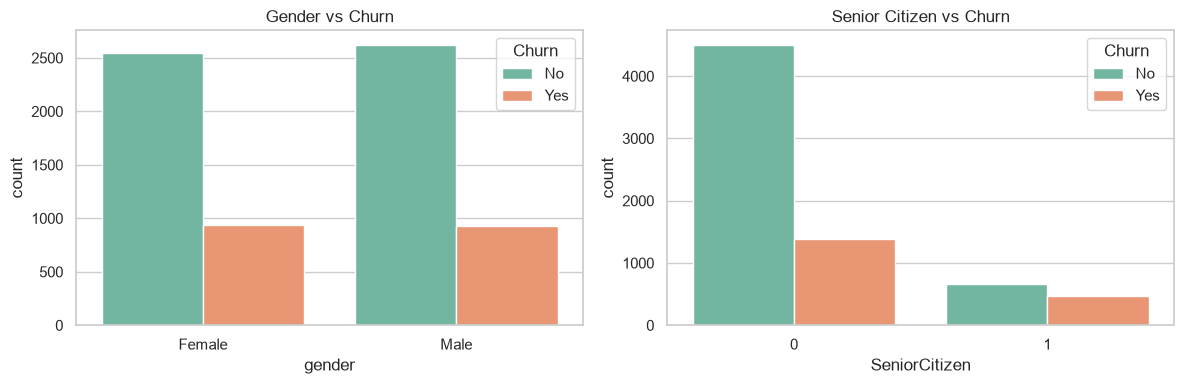

In [5]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.countplot(x='gender', hue='Churn', data=df, palette='Set2')
plt.title('Gender vs Churn')

plt.subplot(1, 2, 2)
sns.countplot(x='SeniorCitizen', hue='Churn', data=df, palette='Set2')
plt.title('Senior Citizen vs Churn')

plt.tight_layout()
plt.savefig('../reports/images/demographics_vs_churn.png', dpi=300)
plt.show()

## 5. Contract Type & Payment Method vs Churn

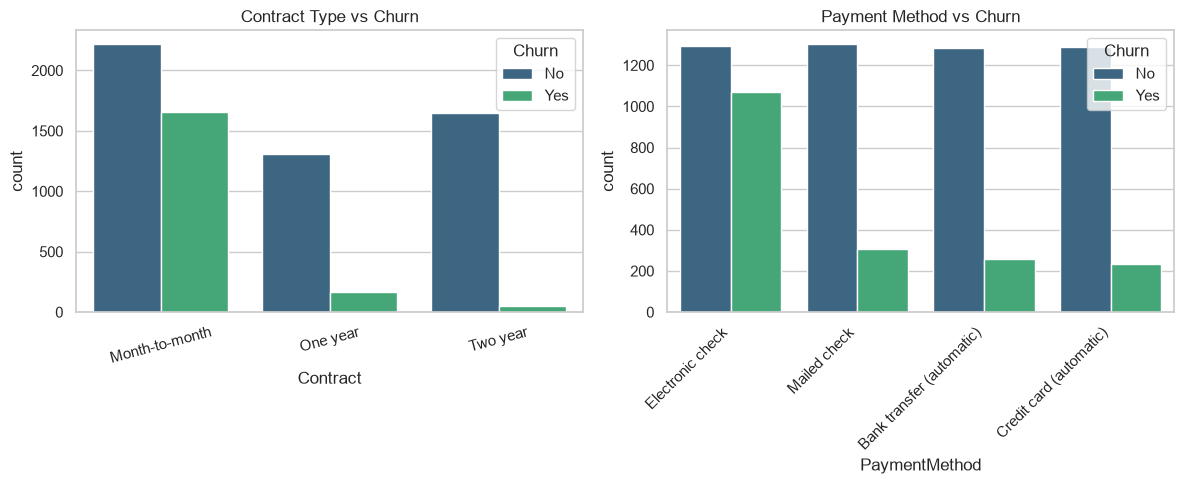

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Contract', hue='Churn', data=df, palette='viridis')
plt.title('Contract Type vs Churn')
plt.xticks(rotation=15)

plt.subplot(1, 2, 2)
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='viridis')
plt.title('Payment Method vs Churn')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../reports/images/contract_payment_vs_churn.png', dpi=300)
plt.show()

## 6. Monthly Charges and Tenure Distributions

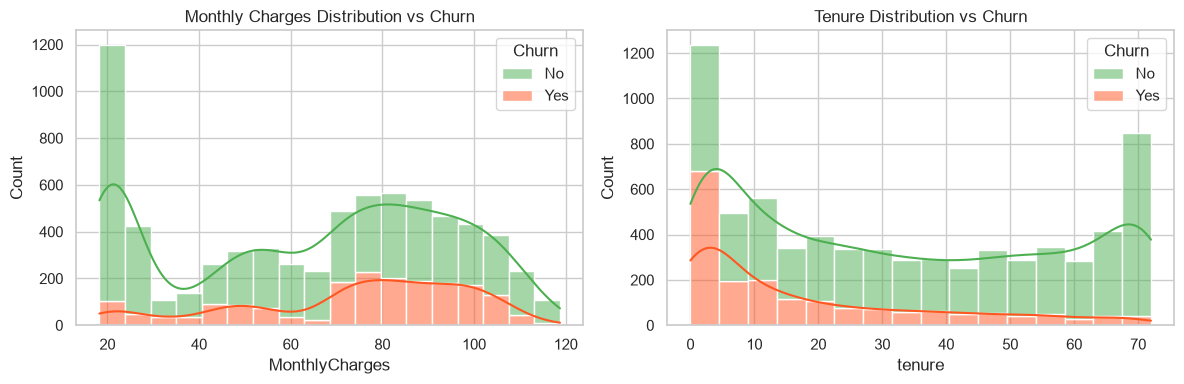

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, multiple='stack', palette=['#4CAF50', '#FF5722'])
plt.title('Monthly Charges Distribution vs Churn')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, multiple='stack', palette=['#4CAF50', '#FF5722'])
plt.title('Tenure Distribution vs Churn')

plt.tight_layout()
plt.savefig('../reports/images/charges_tenure_vs_churn.png', dpi=300)
plt.show()

## 7. Correlation Heatmap of Encoded Features

C:\Users\kp941\AppData\Local\Temp\ipykernel_19504\2531966926.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_corr.select_dtypes(include=['object']).columns:


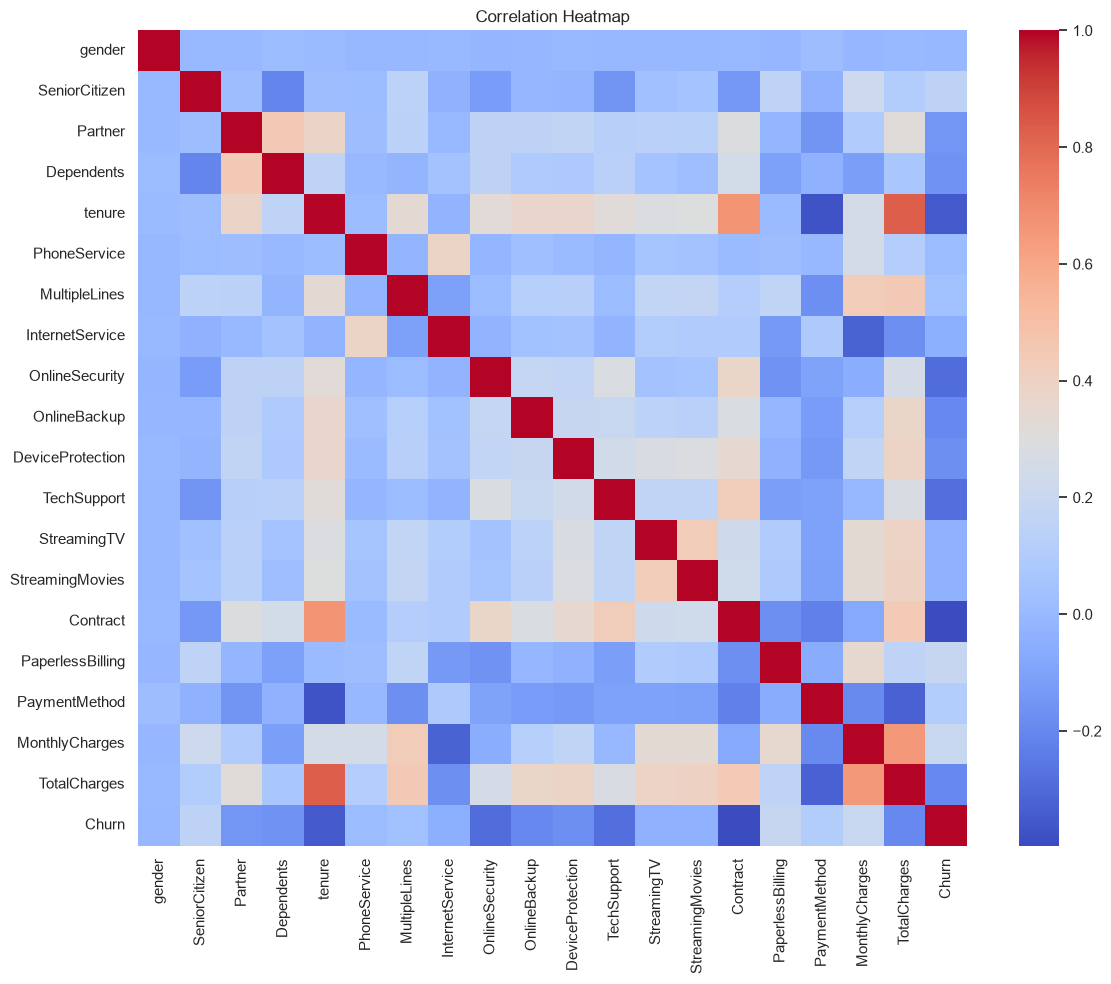

In [8]:
from sklearn.preprocessing import LabelEncoder

df_corr = df.copy().drop(columns=['customerID'])
df_corr['TotalCharges'] = pd.to_numeric(df_corr['TotalCharges'], errors='coerce').fillna(0)

for col in df_corr.select_dtypes(include=['object']).columns:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col])

plt.figure(figsize=(12, 10))
sns.heatmap(df_corr.corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../reports/images/correlation_heatmap_eda.png', dpi=300)
plt.show()